In [1]:
!pip install -q "gymnasium[atari]" ale-py scipy

import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import random
import collections
import gc
import time
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy import ndimage

import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

import torch
import torch.nn as nn
import torch.optim as optim




SEEDS = [1, 2, 3]
EVAL_BASE_SEED = 1000
N_EVAL_EPISODES = 20

BUFFER_CAPACITY = 100_000
TOTAL_STEPS = 1_800_000
LEARNING_STARTS = 20_000
TRAIN_FREQ = 4
EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800_000
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2_000
CHECKPOINTS = [600000, 900000, 1200000, 1500000, 1800000]
HUMAN_BENCHMARK = 9.3

OUTPUT_DIR = Path("baseline_multiseed")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
print("Training seeds:", SEEDS)




torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = False
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.allow_tf32 = False
torch.use_deterministic_algorithms(True)


Dispositivo: cuda
Training seeds: [1, 2, 3]


In [2]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


class FireResetEnv(gym.Wrapper):
    """Premere FIRE all'avvio per servire la pallina."""
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, term, trunc, info = self.env.step(1)
        if term or trunc:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class PongThreeActions(gym.ActionWrapper):
    """Mappa NOOP, UP, DOWN nelle corrispondenti azioni ALE 0, 2, 3."""
    def __init__(self, env, action_seed=None):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)
        if action_seed is not None:
            self.action_space.seed(action_seed)

    def action(self, act):
        return self.action_mapping[int(act)]


def make_env(action_seed=None):
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env, action_seed=action_seed)
    env = FrameStackObservation(env, stack_size=4)
    return env


class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, next_s, done):
        self.buffer.append((
            np.array(s, dtype=np.uint8),
            int(a),
            float(r),
            np.array(next_s, dtype=np.uint8),
            bool(done),
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, next_s, d = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.uint8, device=device).float(),
            torch.tensor(a, dtype=torch.int64, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_s), dtype=torch.uint8, device=device).float(),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=N_EVAL_EPISODES, base_seed=EVAL_BASE_SEED):
    """Valutazione su episodi con seed identici per tutti i modelli."""
    scores = []
    for i in range(episodes):
        episode_seed = base_seed + i
        state, _ = eval_env.reset(seed=episode_seed)


        if model is None:
            eval_env.action_space.seed(episode_seed)

        done = False
        total_reward = 0.0
        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.as_tensor(
                    np.asarray(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.inference_mode():
                    action = int(model(state_t).argmax(dim=1).item())

            state, reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            total_reward += float(reward)

        scores.append(total_reward)

    scores = np.asarray(scores, dtype=np.float32)
    return float(scores.mean()), float(scores.std(ddof=0)), scores


In [3]:

_rand_env = make_env(action_seed=EVAL_BASE_SEED)
rand_mean, rand_std, rand_scores = evaluate(_rand_env, model=None)
_rand_env.close()
print(f"Random Baseline: {rand_mean:.2f} +/- {rand_std:.2f}")


def train_one_seed(seed):
    seed_everything(seed)

    env = make_env(action_seed=seed)
    eval_env = make_env(action_seed=EVAL_BASE_SEED)
    n_actions = env.action_space.n

    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, _ = env.reset(seed=seed)
    ep_reward = 0.0
    rewards_history = []
    step_history = []
    loss_history = []
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()

    for step in range(1, TOTAL_STEPS + 1):
        eps = max(
            EPS_END,
            EPS_START - (EPS_START - EPS_END) * (step / DECAY_STEPS),
        )

        if random.random() < eps:
            action = env.action_space.sample()
        else:
            state_t = torch.as_tensor(
                np.asarray(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.inference_mode():
                action = int(policy_net(state_t).argmax(dim=1).item())

        next_state, reward, term, trunc, _ = env.step(action)


        buffer.push(state, action, reward, next_state, term)

        state = next_state
        ep_reward += float(reward)

        if term or trunc:
            rewards_history.append(ep_reward)
            step_history.append(step)

            if len(rewards_history) % 20 == 0:
                avg_recent = np.mean(rewards_history[-20:])
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"[seed {seed}] Step {step:7d}/{TOTAL_STEPS} | "
                    f"Episodio {len(rewards_history):4d} | "
                    f"Media ultimi 20: {avg_recent:6.2f} | "
                    f"eps: {eps:.3f} | {elapsed:.1f} min",
                    flush=True,
                )

            state, _ = env.reset()
            ep_reward = 0.0

        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_d = buffer.sample(BATCH_SIZE)

            with torch.no_grad():
                max_next_q = target_net(b_ns).max(dim=1).values
                target_q = b_r + (1.0 - b_d) * GAMMA * max_next_q

            current_q = policy_net(b_s).gather(1, b_a.unsqueeze(1)).squeeze(1)
            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100_000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            policy_net.eval()
            m_score, s_score, scores = evaluate(eval_env, model=policy_net)
            policy_net.train()

            checkpoint_results[step] = {
                "mean": m_score,
                "episode_std": s_score,
                "scores": scores.tolist(),
            }

            ckpt_path = CHECKPOINT_DIR / f"dqn_pong_seed{seed}_{step}.pth"
            torch.save(policy_net.state_dict(), ckpt_path)

            print(
                f"\n--- seed {seed} | checkpoint {step}: "
                f"{m_score:.2f} +/- {s_score:.2f} ---\n",
                flush=True,
            )

    env.close()
    eval_env.close()

    np.savez_compressed(
        OUTPUT_DIR / f"baseline_seed{seed}_history.npz",
        step_history=np.asarray(step_history, dtype=np.int64),
        rewards_history=np.asarray(rewards_history, dtype=np.float32),
        loss_history=np.asarray(loss_history, dtype=np.float32),
    )

    final_path = CHECKPOINT_DIR / f"dqn_pong_seed{seed}_{TOTAL_STEPS}.pth"

    result = {
        "seed": seed,
        "checkpoints": checkpoint_results,
        "final_checkpoint": str(final_path),
        "n_episodes": len(rewards_history),
        "n_updates": len(loss_history),
    }


    del buffer, optimizer, target_net, policy_net
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


runs = {}
for seed in SEEDS:
    print("\n" + "=" * 80)
    print(f"TRAINING VANILLA DQN — seed {seed}")
    print("=" * 80)
    runs[seed] = train_one_seed(seed)

print("\nTre training completati.")


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Random Baseline: -20.40 +/- 0.86

TRAINING VANILLA DQN — seed 1
[seed 1] Step   18974/1800000 | Episodio   20 | Media ultimi 20: -20.60 | eps: 0.977 | 0.4 min
[seed 1] Step   38562/1800000 | Episodio   40 | Media ultimi 20: -20.70 | eps: 0.952 | 1.3 min
[seed 1] Step   57959/1800000 | Episodio   60 | Media ultimi 20: -20.60 | eps: 0.928 | 2.3 min
[seed 1] Step   77809/1800000 | Episodio   80 | Media ultimi 20: -20.45 | eps: 0.904 | 3.4 min
[seed 1] Step   98988/1800000 | Episodio  100 | Media ultimi 20: -20.50 | eps: 0.878 | 4.5 min
[seed 1] Step  119852/1800000 | Episodio  120 | Media ultimi 20: -20.40 | eps: 0.852 | 5.6 min
[seed 1] Step  143720/1800000 | Episodio  140 | Media ultimi 20: -19.60 | eps: 0.822 | 6.8 min
[seed 1] Step  167167/1800000 | Episodio  160 | Media ultimi 20: -19.95 | eps: 0.793 | 8.0 min
[seed 1] Step  191742/1800000 | Episodio  180 | Media ultimi 20: -19.60 | eps: 0.763 | 9.2 min
[seed 1] Step  219162/1800000 | Episodio  200 | Media ultimi 20: -19.35 | eps: 0.


--- RISULTATI AGGREGATI VANILLA DQN ---
Random Agent: -20.40 +/- 0.86 (variabilità tra episodi)
Human reference: 9.30
 600k | mean across seeds = -10.18 +/- 3.83 | 1: -7.40, 2: -14.55, 3: -8.60
 900k | mean across seeds = 0.55 +/- 6.20 | 1: -0.75, 2: -4.90, 3: 7.30
1200k | mean across seeds = 11.15 +/- 1.23 | 1: 9.85, 2: 12.30, 3: 11.30
1500k | mean across seeds = 13.45 +/- 4.07 | 1: 15.85, 2: 8.75, 3: 15.75
1800k | mean across seeds = 13.45 +/- 2.38 | 1: 14.85, 2: 14.80, 3: 10.70


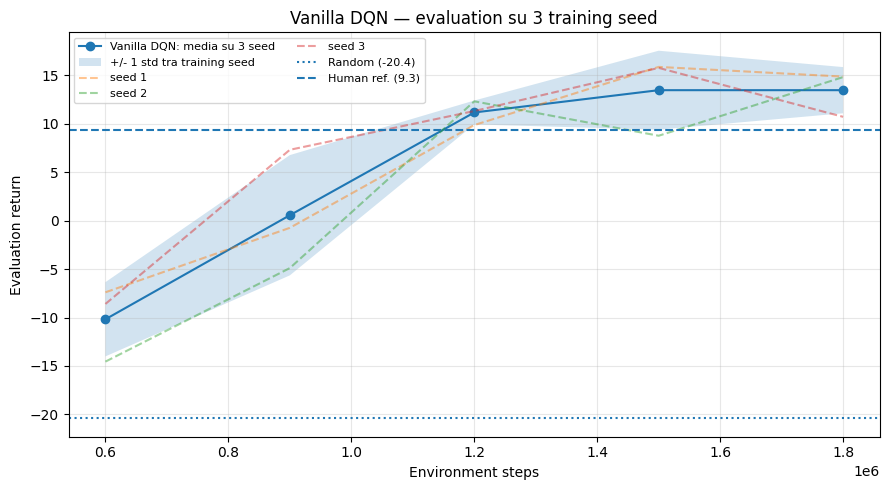

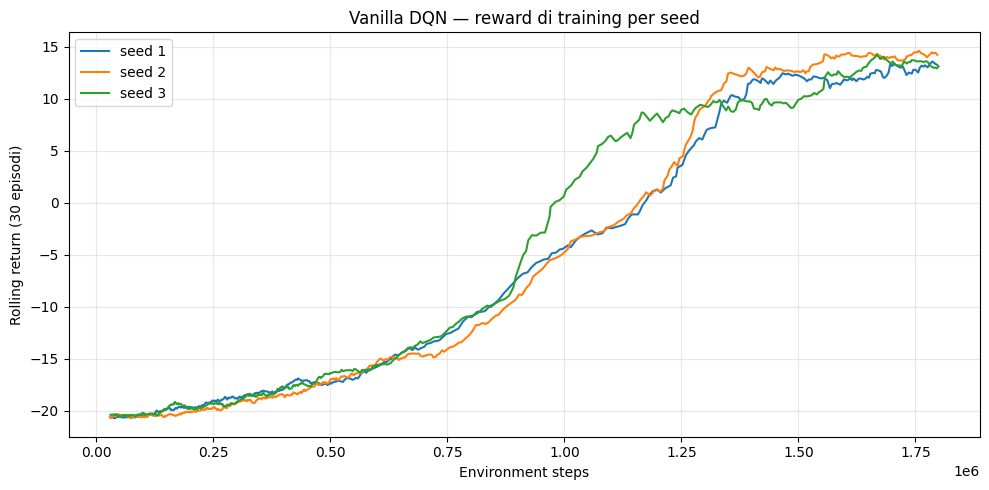

In [4]:



checkpoint_matrix = np.asarray([
    [runs[s]["checkpoints"][step]["mean"] for step in CHECKPOINTS]
    for s in SEEDS
], dtype=np.float64)

mean_across_seeds = checkpoint_matrix.mean(axis=0)
std_across_seeds = checkpoint_matrix.std(axis=0, ddof=1)

print("\n--- RISULTATI AGGREGATI VANILLA DQN ---")
print(f"Random Agent: {rand_mean:.2f} +/- {rand_std:.2f} (variabilità tra episodi)")
print(f"Human reference: {HUMAN_BENCHMARK:.2f}")
for j, step in enumerate(CHECKPOINTS):
    individual = ", ".join(
        f"{seed}: {checkpoint_matrix[i, j]:.2f}"
        for i, seed in enumerate(SEEDS)
    )
    print(
        f"{step//1000:4d}k | mean across seeds = "
        f"{mean_across_seeds[j]:.2f} +/- {std_across_seeds[j]:.2f} | {individual}"
    )

summary = {
    "algorithm": "Vanilla DQN",
    "training_seeds": SEEDS,
    "evaluation_base_seed": EVAL_BASE_SEED,
    "evaluation_episodes": N_EVAL_EPISODES,
    "random_baseline": {
        "mean": rand_mean,
        "episode_std": rand_std,
        "scores": rand_scores.tolist(),
    },
    "checkpoints": {},
}
for j, step in enumerate(CHECKPOINTS):
    summary["checkpoints"][str(step)] = {
        "mean_across_training_seeds": float(mean_across_seeds[j]),
        "std_across_training_seeds": float(std_across_seeds[j]),
        "per_seed": {
            str(seed): runs[seed]["checkpoints"][step]
            for seed in SEEDS
        },
    }

with open(OUTPUT_DIR / "baseline_multiseed_summary.json", "w") as f:
    json.dump(summary, f, indent=2)


fig, ax = plt.subplots(figsize=(9, 5))
x = np.asarray(CHECKPOINTS)
ax.plot(x, mean_across_seeds, marker="o", label="Vanilla DQN: media su 3 seed")
ax.fill_between(
    x,
    mean_across_seeds - std_across_seeds,
    mean_across_seeds + std_across_seeds,
    alpha=0.2,
    label="+/- 1 std tra training seed",
)
for i, seed in enumerate(SEEDS):
    ax.plot(x, checkpoint_matrix[i], linestyle="--", alpha=0.45, label=f"seed {seed}")
ax.axhline(rand_mean, linestyle=":", label=f"Random ({rand_mean:.1f})")
ax.axhline(HUMAN_BENCHMARK, linestyle="--", label=f"Human ref. ({HUMAN_BENCHMARK})")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Evaluation return")
ax.set_title("Vanilla DQN — evaluation su 3 training seed")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_multiseed_evaluation.png", dpi=160)
plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 5))
for seed in SEEDS:
    h = np.load(OUTPUT_DIR / f"baseline_seed{seed}_history.npz")
    rewards = h["rewards_history"]
    steps = h["step_history"]
    if len(rewards) >= 30:
        rolling = np.convolve(rewards, np.ones(30) / 30.0, mode="valid")
        ax.plot(steps[29:], rolling, label=f"seed {seed}")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Rolling return (30 episodi)")
ax.set_title("Vanilla DQN — reward di training per seed")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_training_rewards_3seeds.png", dpi=160)
plt.show()
plt.close(fig)


In [5]:



VIS_SEED = 314159
VIS_ROLLOUT_STEPS = 12_000
VIS_MAX_SAMPLES = 3_000
VIS_BATCH_SIZE = 128
VIS_PROBE_EPS = 0.05
VIS_MIN_BIN = 5
VIS_MIN_PURITY = 0.60

ACTION_NAMES = ["NOOP", "UP", "DOWN"]


def load_final_model(seed):
    path = CHECKPOINT_DIR / f"dqn_pong_seed{seed}_{TOTAL_STEPS}.pth"
    weights = torch.load(path, map_location="cpu", weights_only=True)
    model = DQN(3).to(device)
    model.load_state_dict(weights, strict=True)
    model.eval()
    return model


def _components(mask):
    labels, _ = ndimage.label(mask)
    found = []
    for idx, box in enumerate(ndimage.find_objects(labels), start=1):
        if box is None:
            continue
        ys, xs = np.where(labels[box] == idx)
        h = box[0].stop - box[0].start
        w = box[1].stop - box[1].start
        found.append((
            xs.mean() + box[1].start,
            ys.mean() + box[0].start,
            w,
            h,
            len(xs),
        ))
    return found


def detect_ball_and_right_paddle(rgb):
    """Detector euristico SOLO per la visualizzazione, mai per il training."""
    if rgb.shape != (210, 160, 3):
        return None


    ball_mask = np.all(rgb > 180, axis=-1)
    ball_mask[:34] = False
    ball_mask[194:] = False
    ball_mask[:, :10] = False
    ball_mask[:, 150:] = False

    balls = [
        c for c in _components(ball_mask)
        if 1 <= c[2] <= 5 and 1 <= c[3] <= 6 and 2 <= c[4] <= 24
    ]



    background = np.median(
        rgb[40:190, 20:135].reshape(-1, 3), axis=0
    )
    foreground = np.max(
        np.abs(rgb.astype(np.float32) - background), axis=-1
    ) > 30
    foreground[:34] = False
    foreground[194:] = False
    foreground[:, :136] = False
    foreground[:, 151:] = False

    paddles = [
        c for c in _components(foreground)
        if 1 <= c[2] <= 6 and 7 <= c[3] <= 25 and c[4] >= 10
    ]

    if len(balls) != 1 or len(paddles) != 1:
        return None

    bx, by = balls[0][:2]
    px, py = paddles[0][:2]
    return np.asarray([bx, by, px, py], dtype=np.float32)


def collect_common_probe_dataset():
    rng = np.random.default_rng(VIS_SEED)
    n_models = len(SEEDS)
    n_each = VIS_MAX_SAMPLES // n_models
    steps_each = VIS_ROLLOUT_STEPS // n_models

    if steps_each < n_each:
        raise ValueError("VIS_ROLLOUT_STEPS deve essere >= VIS_MAX_SAMPLES.")

    n_total = n_each * n_models
    data = {
        "states": np.empty((n_total, 4, 84, 84), dtype=np.uint8),
        "next_last": np.empty((n_total, 84, 84), dtype=np.uint8),
        "actions": np.empty(n_total, dtype=np.int64),
        "rewards": np.empty(n_total, dtype=np.float32),
        "terminated": np.empty(n_total, dtype=bool),
        "truncated": np.empty(n_total, dtype=bool),

        "features": np.full((n_total, 3), np.nan, dtype=np.float32),
        "donor_seed": np.empty(n_total, dtype=np.int64),
    }

    previews = []
    detected = 0
    seen = 0

    for donor_idx, seed in enumerate(SEEDS):
        model = load_final_model(seed)
        env = make_env(action_seed=VIS_SEED + donor_idx)
        state, _ = env.reset(seed=VIS_SEED + donor_idx)
        previous_obj = None

        for step in range(steps_each):

            rgb = env.unwrapped.ale.getScreenRGB()
            obj = detect_ball_and_right_paddle(rgb)

            features = np.full(3, np.nan, dtype=np.float32)
            if obj is not None:
                detected += 1
                features[0] = obj[0]
                features[1] = obj[1] - obj[3]

                if previous_obj is not None:
                    dx = obj[0] - previous_obj[0]
                    if 0.25 <= abs(dx) <= 25:
                        features[2] = dx

                if len(previews) < 6 and step % 100 == 0:
                    previews.append((rgb.copy(), obj.copy()))

            seen += 1

            s_t = torch.as_tensor(
                np.asarray(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.inference_mode():
                action = int(model(s_t).argmax(dim=1).item())



            if rng.random() < VIS_PROBE_EPS:
                action = int(rng.integers(0, 3))

            next_state, reward, term, trunc, _ = env.step(action)


            slot = step if step < n_each else int(rng.integers(step + 1))
            if slot < n_each:
                i = donor_idx * n_each + slot
                data["states"][i] = np.asarray(state, dtype=np.uint8)
                data["next_last"][i] = np.asarray(next_state, dtype=np.uint8)[-1]
                data["actions"][i] = action
                data["rewards"][i] = float(reward)
                data["terminated"][i] = bool(term)
                data["truncated"][i] = bool(trunc)
                data["features"][i] = features
                data["donor_seed"][i] = seed

            state = next_state
            previous_obj = obj if reward == 0 else None

            if term or trunc:
                state, _ = env.reset()
                previous_obj = None

        env.close()
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            f"Probe donor seed {seed}: {steps_each} passi, "
            f"{n_each} transizioni conservate."
        )

    coverage = detected / max(seen, 1)
    print(f"Copertura detector pallina/racchetta: {coverage:.1%}")
    if coverage < 0.50:
        warnings.warn(
            "Copertura geometrica < 50%: interpretare le heatmap con cautela "
            "e controllare detector_check.png."
        )

    return data, previews


probe, detector_previews = collect_common_probe_dataset()
print("Probe dataset:", probe["states"].shape)


Probe donor seed 1: 4000 passi, 1000 transizioni conservate.
Probe donor seed 2: 4000 passi, 1000 transizioni conservate.
Probe donor seed 3: 4000 passi, 1000 transizioni conservate.
Copertura detector pallina/racchetta: 62.0%
Probe dataset: (3000, 4, 84, 84)


In [6]:
def score_model_on_probe(seed, data):
    online = load_final_model(seed)



    target = load_final_model(seed)

    q_chunks = []
    td_chunks = []

    for start in range(0, len(data["actions"]), VIS_BATCH_SIZE):
        stop = min(start + VIS_BATCH_SIZE, len(data["actions"]))
        sl = slice(start, stop)

        s = torch.as_tensor(
            data["states"][sl], dtype=torch.uint8, device=device
        ).float()

        ns_np = np.concatenate(
            [
                data["states"][sl, 1:],
                data["next_last"][sl, None],
            ],
            axis=1,
        )
        ns = torch.as_tensor(
            ns_np, dtype=torch.uint8, device=device
        ).float()

        with torch.inference_mode():
            q = online(s).cpu().numpy()
            next_q_target = target(ns).cpu().numpy()

        actions = data["actions"][sl]
        rewards = data["rewards"][sl]
        terminated = data["terminated"][sl].astype(np.float32)

        bootstrap = next_q_target.max(axis=1)
        td_target = rewards + GAMMA * (1.0 - terminated) * bootstrap
        td_error = td_target - q[np.arange(len(q)), actions]

        q_chunks.append(q)
        td_chunks.append(td_error)

    q = np.concatenate(q_chunks, axis=0)
    td = np.concatenate(td_chunks, axis=0)

    sorted_q = np.sort(q, axis=1)
    action_gap = sorted_q[:, -1] - sorted_q[:, -2]
    greedy_actions = q.argmax(axis=1)

    del online, target
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "q": q,
        "td": td,
        "action_gap": action_gap,
        "greedy_actions": greedy_actions,
    }


diagnostics = {
    seed: score_model_on_probe(seed, probe)
    for seed in SEEDS
}


diagnostic_summary = {}
for seed in SEEDS:
    d = diagnostics[seed]
    diagnostic_summary[str(seed)] = {
        "td_mean": float(np.mean(d["td"])),
        "td_mae": float(np.mean(np.abs(d["td"]))),
        "td_std": float(np.std(d["td"], ddof=0)),
        "td_p95_abs": float(np.quantile(np.abs(d["td"]), 0.95)),
        "q_mean_by_action": {
            ACTION_NAMES[a]: float(d["q"][:, a].mean())
            for a in range(3)
        },
        "q_std_by_action": {
            ACTION_NAMES[a]: float(d["q"][:, a].std(ddof=0))
            for a in range(3)
        },
        "max_q_mean": float(d["q"].max(axis=1).mean()),
        "action_gap_mean": float(d["action_gap"].mean()),
        "greedy_action_frequency": {
            ACTION_NAMES[a]: float(np.mean(d["greedy_actions"] == a))
            for a in range(3)
        },
    }

with open(OUTPUT_DIR / "baseline_visualization_diagnostics.json", "w") as f:
    json.dump(diagnostic_summary, f, indent=2)

print(json.dumps(diagnostic_summary, indent=2))


{
  "1": {
    "td_mean": 0.0069771879352629185,
    "td_mae": 0.052183378487825394,
    "td_std": 0.08893849700689316,
    "td_p95_abs": 0.16847604513168335,
    "q_mean_by_action": {
      "NOOP": 0.5791170597076416,
      "UP": 0.5864700675010681,
      "DOWN": 0.5731102824211121
    },
    "q_std_by_action": {
      "NOOP": 0.3575464189052582,
      "UP": 0.35098621249198914,
      "DOWN": 0.366868257522583
    },
    "max_q_mean": 0.609620213508606,
    "action_gap_mean": 0.031023643910884857,
    "greedy_action_frequency": {
      "NOOP": 0.31833333333333336,
      "UP": 0.3393333333333333,
      "DOWN": 0.3423333333333333
    }
  },
  "2": {
    "td_mean": 0.0068580880761146545,
    "td_mae": 0.05248403549194336,
    "td_std": 0.08924154192209244,
    "td_p95_abs": 0.16692550480365753,
    "q_mean_by_action": {
      "NOOP": 0.6432751417160034,
      "UP": 0.654107928276062,
      "DOWN": 0.6345111727714539
    },
    "q_std_by_action": {
      "NOOP": 0.3469811975955963,
      

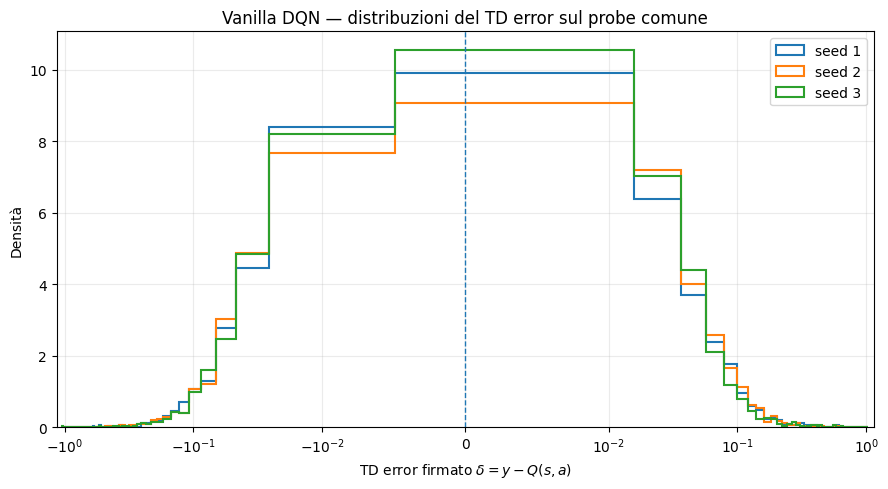

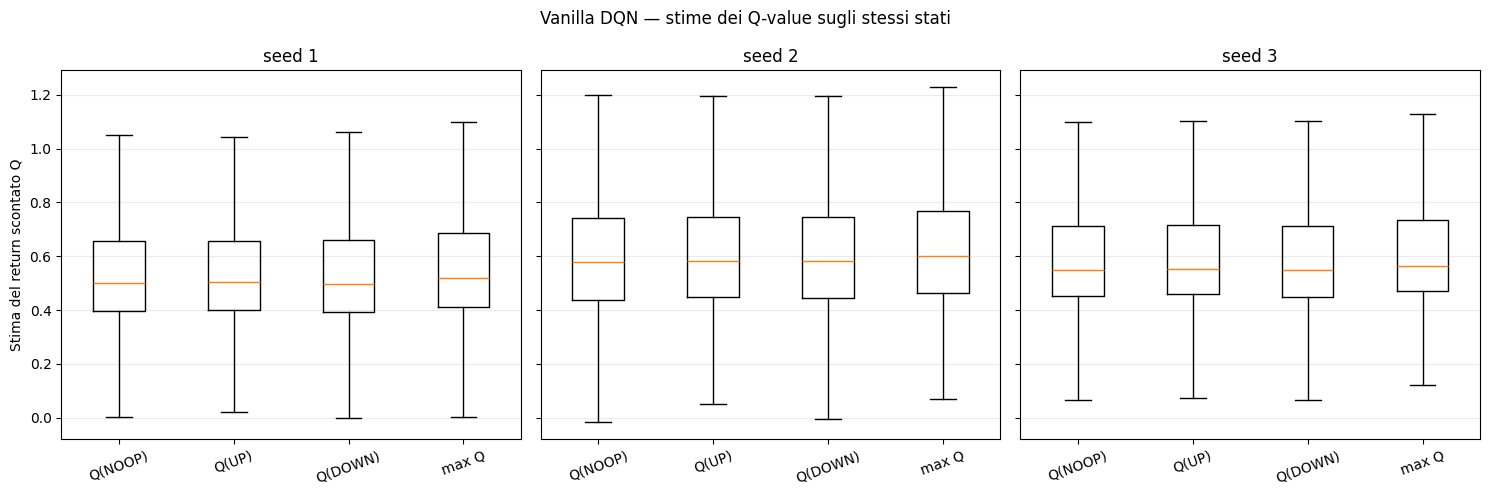

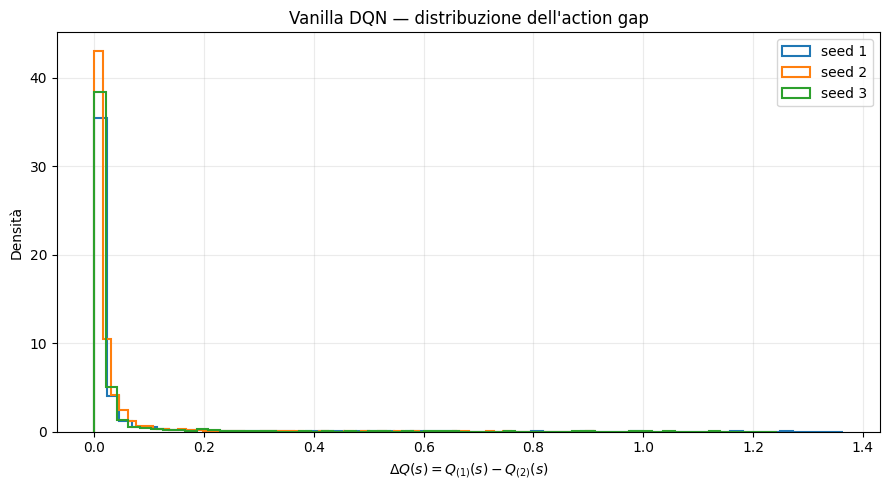

In [7]:

fig, ax = plt.subplots(figsize=(9, 5))
all_td = np.concatenate([diagnostics[s]["td"] for s in SEEDS])
bins = np.histogram_bin_edges(all_td, bins=100)

for seed in SEEDS:
    ax.hist(
        diagnostics[seed]["td"],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=f"seed {seed}",
    )

ax.axvline(0.0, linestyle="--", linewidth=1)
ax.set_xscale("symlog", linthresh=0.01)
ax.set_xlabel(r"TD error firmato $\delta = y-Q(s,a)$")
ax.set_ylabel("Densità")
ax.set_title("Vanilla DQN — distribuzioni del TD error sul probe comune")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_td_error_distributions.png", dpi=170)
plt.show()
plt.close(fig)



fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 5), sharey=True)
for ax, seed in zip(axes, SEEDS):
    q = diagnostics[seed]["q"]
    values = [q[:, 0], q[:, 1], q[:, 2], q.max(axis=1)]
    ax.boxplot(values, showfliers=False)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Q(NOOP)", "Q(UP)", "Q(DOWN)", "max Q"], rotation=20)
    ax.set_title(f"seed {seed}")
    ax.grid(True, axis="y", alpha=0.25)

axes[0].set_ylabel("Stima del return scontato Q")
fig.suptitle("Vanilla DQN — stime dei Q-value sugli stessi stati")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_q_value_estimates.png", dpi=170)
plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(9, 5))
for seed in SEEDS:
    ax.hist(
        diagnostics[seed]["action_gap"],
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=f"seed {seed}",
    )
ax.set_xlabel(r"$\Delta Q(s)=Q_{(1)}(s)-Q_{(2)}(s)$")
ax.set_ylabel("Densità")
ax.set_title("Vanilla DQN — distribuzione dell'action gap")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_action_gap.png", dpi=170)
plt.show()
plt.close(fig)


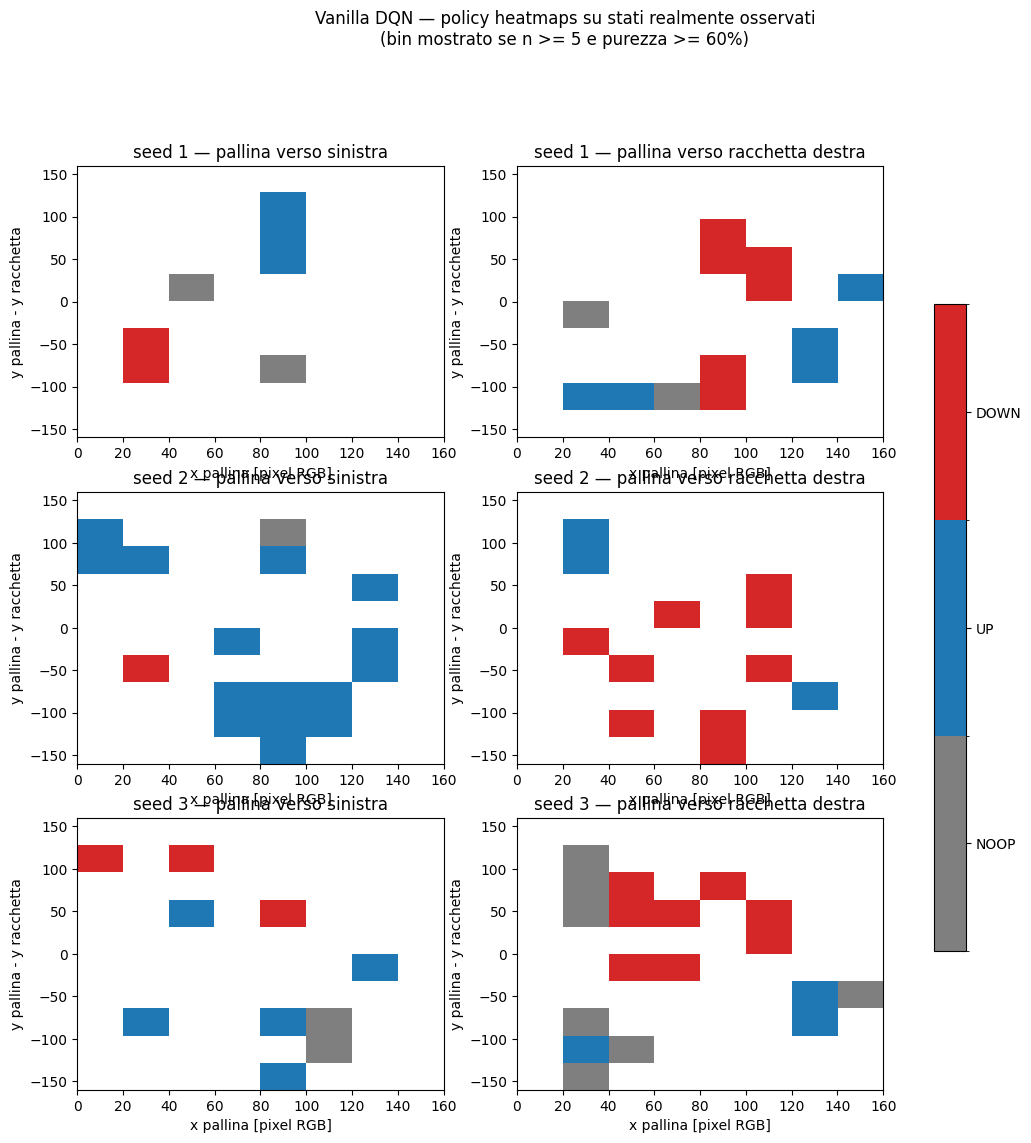

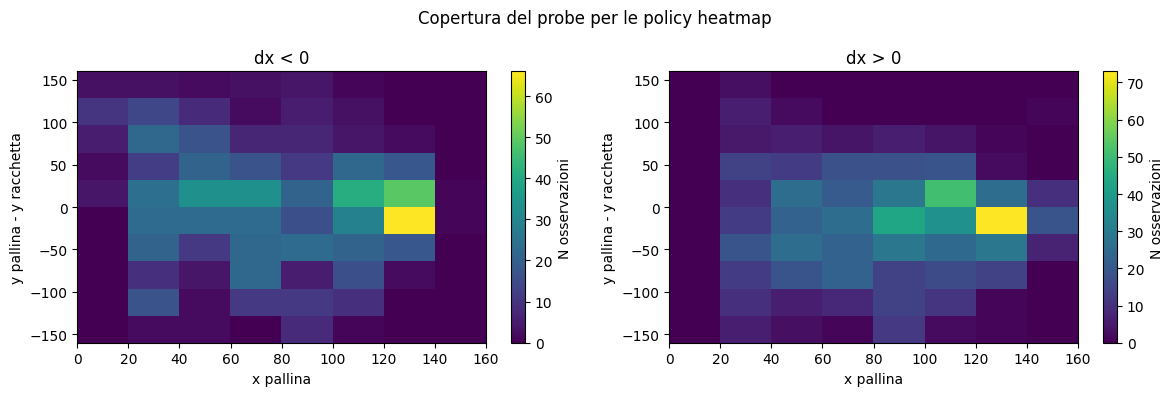

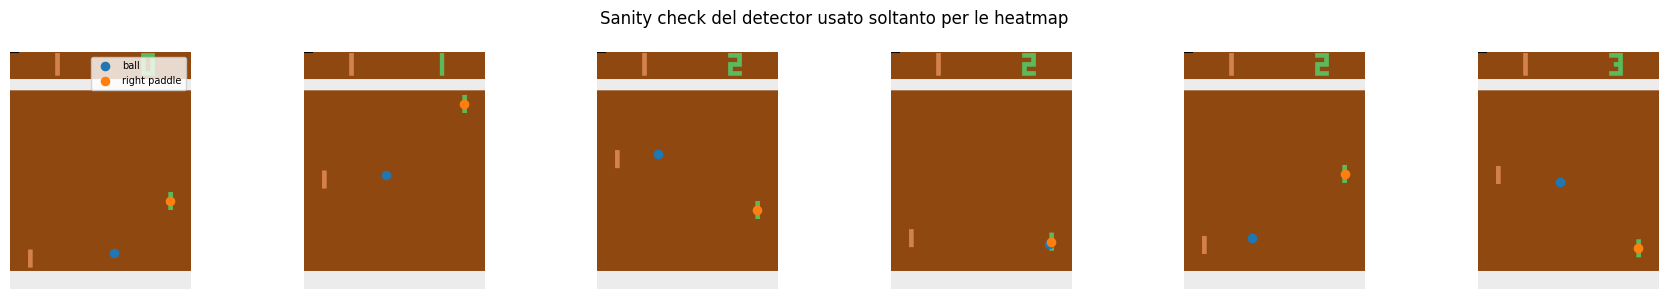

Output salvati in: /kaggle/working/baseline_multiseed


In [8]:
def policy_heatmap(features, greedy_actions, direction):
    x_edges = np.linspace(0, 160, 9)
    y_edges = np.linspace(-160, 160, 11)

    valid = (
        np.isfinite(features).all(axis=1)
        & (direction * features[:, 2] > 0)
    )

    f = features[valid]
    a = greedy_actions[valid]

    counts = np.stack([
        np.histogram2d(
            f[a == action, 1],
            f[a == action, 0],
            bins=[y_edges, x_edges],
        )[0]
        for action in range(3)
    ])

    occupancy = counts.sum(axis=0)
    modal_action = counts.argmax(axis=0).astype(float)
    purity = counts.max(axis=0) / np.maximum(occupancy, 1)


    modal_action[
        (occupancy < VIS_MIN_BIN)
        | (purity < VIS_MIN_PURITY)
    ] = np.nan

    return modal_action, occupancy, purity, x_edges, y_edges


cmap = ListedColormap(["#7f7f7f", "#1f77b4", "#d62728"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)


fig, axes = plt.subplots(
    len(SEEDS),
    2,
    figsize=(12.5, 10.5),
    sharex=True,
    sharey=True,
    layout="constrained",
    squeeze=False,
)

for row, seed in enumerate(SEEDS):
    actions = diagnostics[seed]["greedy_actions"]

    for col, direction in enumerate([-1, +1]):
        heat, occupancy, purity, x_edges, y_edges = policy_heatmap(
            probe["features"], actions, direction
        )

        ax = axes[row, col]
        im = ax.imshow(
            heat,
            origin="lower",
            aspect="auto",
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )

        if row == 0:
            direction_name = (
                "Pallina verso sinistra"
                if direction < 0
                else "Pallina verso la racchetta destra"
            )
            ax.set_title(direction_name, fontsize=12, pad=8)

        if col == 0:
            ax.annotate(
                f"Seed {seed}",
                xy=(-0.16, 0.5),
                xycoords="axes fraction",
                rotation=90,
                va="center",
                ha="center",
                fontsize=11,
                fontweight="bold",
            )

        ax.tick_params(labelsize=9)

fig.supxlabel("Posizione orizzontale della pallina [pixel RGB]", fontsize=11)
fig.supylabel(
    "Disallineamento verticale: y pallina - y racchetta [pixel RGB]",
    fontsize=11,
)

cbar = fig.colorbar(
    im,
    ax=axes,
    ticks=[0, 1, 2],
    shrink=0.74,
    pad=0.025,
)
cbar.ax.set_yticklabels(ACTION_NAMES)
cbar.set_label("Azione greedy", fontsize=10)

fig.suptitle(
    "Vanilla DQN - proiezione empirica della policy su stati osservati\n"
    f"Bin visualizzato se n >= {VIS_MIN_BIN} e purezza >= {VIS_MIN_PURITY:.0%}",
    fontsize=13,
)
fig.savefig(
    FIGURE_DIR / "baseline_policy_heatmaps.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)



fig, axes = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
for col, direction in enumerate([-1, +1]):
    _, occupancy, _, x_edges, y_edges = policy_heatmap(
        probe["features"], diagnostics[SEEDS[0]]["greedy_actions"], direction
    )

    ax = axes[0, col]
    im_occ = ax.imshow(
        occupancy,
        origin="lower",
        aspect="auto",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        interpolation="nearest",
    )
    ax.set_title("dx < 0" if direction < 0 else "dx > 0")
    ax.set_xlabel("x pallina")
    ax.set_ylabel("y pallina - y racchetta")
    fig.colorbar(im_occ, ax=ax, label="N osservazioni")

fig.suptitle("Copertura del probe per le policy heatmap")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_policy_heatmap_coverage.png", dpi=170)
plt.show()
plt.close(fig)



if detector_previews:
    n = len(detector_previews)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3), squeeze=False)
    for ax, (rgb, obj) in zip(axes[0], detector_previews):
        bx, by, px, py = obj
        ax.imshow(rgb)
        ax.scatter([bx], [by], s=35, label="ball")
        ax.scatter([px], [py], s=35, label="right paddle")
        ax.set_axis_off()
    axes[0, 0].legend(fontsize=7)
    fig.suptitle("Sanity check del detector usato soltanto per le heatmap")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "detector_check.png", dpi=160)
    plt.show()
    plt.close(fig)

print(f"Output salvati in: {OUTPUT_DIR.resolve()}")
